In [1]:
import numpy as np
import pandas as pd
import scipy
import scipy.stats
import matplotlib as mpl   
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import t, norm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
def get_stock_data(ticker, max, start_date, end_date):
    try:
        # https://medium.com/nerd-for-tech/all-you-need-to-know-about-yfinance-yahoo-finance-library-fa4c6e48f08e
        data = yf.Ticker(ticker)
        if max == False:
            data = data.history(start=start_date, end=end_date)
        else:
            data = data.history(period="max")
        return data
    except Exception as e:
        return f"Error fetching data: {e}"

In [3]:
#demo index
stock_data = get_stock_data("PREIX", False,"2000-01-01", "2024-10-01")
stock_data.asfreq('B').index  # set index frequency to business daliy
stock_data['Daily Return'] = stock_data['Close'].pct_change()  # percentage return
stock_data['Log Return'] = np.log(stock_data['Close'] / stock_data['Close'].shift(1))

In [4]:
#simple threshold determination (based on SD, mean, etc. -- to be experimented with)

mean_return = stock_data['Daily Return'].mean()
std_return = stock_data['Daily Return'].std()

# Define thresholds
up_threshold = mean_return + std_return
down_threshold = mean_return - std_return

def classify_state(return_value, up_thresh, down_thresh):
    if return_value > up_thresh:
        return 'Up'
    elif return_value < down_thresh:
        return 'Down'
    else:
        return 'Stagnant'

stock_data['Markov State'] = stock_data['Daily Return'].apply(lambda x: classify_state(x, up_threshold, down_threshold))

In [5]:
#transition matrix creation (probabilities of achieving various states based on prev states)

# Shift 'Markov State' column to get previous state
stock_data['Prev State'] = stock_data['Markov State'].shift(1)

# Create a transition matrix and Normalize to get probabilities
transition_counts = pd.crosstab(stock_data['Prev State'], stock_data['Markov State'])
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)

In [6]:
#establish stationary equilibrium matrix

def find_equilibrium(P):
    """
    Compute stationary distribution of a Markov transition matrix P.
    Assumes P is row-stochastic (rows sum to 1).
    """

    # Ensure rows sum to 1 (defensive normalization)
    P = P / P.sum(axis=1, keepdims=True)

    # Compute eigenvalues/eigenvectors of P^T
    eigvals, eigvecs = np.linalg.eig(P.T)

    # Find eigenvector corresponding to eigenvalue 1
    idx = np.argmin(np.abs(eigvals - 1))
    stationary = np.real(eigvecs[:, idx])

    # Normalize to sum to 1
    stationary = stationary / stationary.sum()

    # Ensure non-negative (numerical safeguard)
    stationary = np.maximum(stationary, 0)
    stationary = stationary / stationary.sum()

    return stationary
#check normalization there bud

In [7]:
from arch import arch_model

# Scale returns for numerical stability (important)
returns = stock_data['Log Return'].dropna() * 100

# Fit GARCH(1,1) with Student-t errors
garch = arch_model(
    returns,
    mean='Constant',      # could change later
    vol='GARCH',
    p=1,
    q=1,
    dist='t'
)

garch_res = garch.fit(disp="off")

print(garch_res.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   Log Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -8444.98
Distribution:      Standardized Student's t   AIC:                           16900.0
Method:                  Maximum Likelihood   BIC:                           16933.6
                                              No. Observations:                 6224
Date:                      Sat, Mar 21 2026   Df Residuals:                     6223
Time:                              18:39:50   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

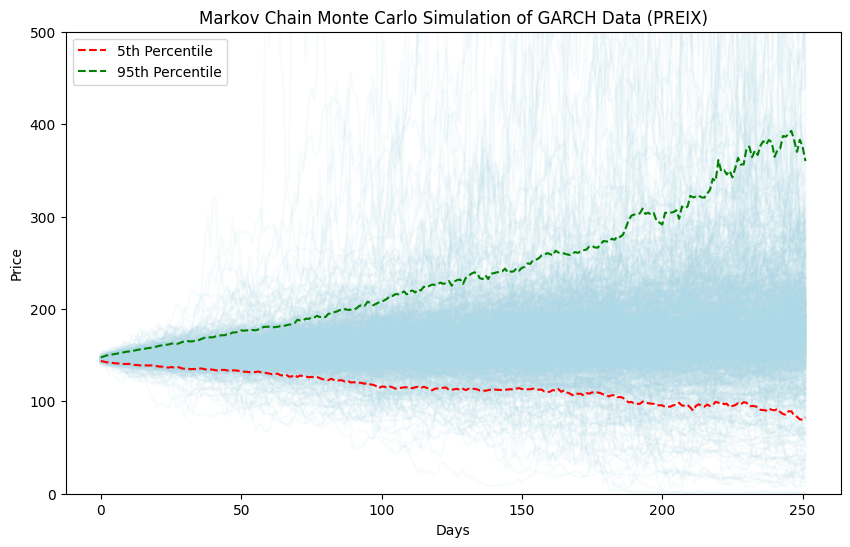

In [8]:
#mc sim

params = garch_res.params

mu = params['mu']
omega = params['omega']
alpha = params['alpha[1]']
beta = params['beta[1]']
# # Cap alpha + beta to avoid near-IGARCH
if alpha + beta > 0.97:
    scale = 0.97 / (alpha + beta)
    alpha *= scale
    beta *= scale
nu = params['nu']  # degrees of freedom
last_vol = garch_res.conditional_volatility.iloc[-1]
last_resid = garch_res.resid.iloc[-1]

initial_price = stock_data['Close'].iloc[-1]  # Initial stock price
states = ["Down", "Stagnant", "Up"]

# 4. Monte Carlo Simulation based on Markov Chain
n_simulations = 1000  # Number of simulation paths
n_days = 252  # Simulate for 1 year (252 trading days)

# Initial state probabilities
initial_state = stock_data['Markov State'].iloc[-1]
initial_state_probabilities = [1 if state == initial_state else 0 for state in states]

# Simulating the paths
simulated_paths = []
for sim in range(n_simulations):
    simulated_returns = []
    current_state = np.random.choice(states, p=initial_state_probabilities)
    sigma_t = last_vol
    r_prev = last_resid
    
    for day in range(n_days):
        #Simulate return based on the current state using Student's t-distribution
        # Update conditional variance
        sigma2_t = omega + alpha * (r_prev ** 2) + beta * (sigma_t ** 2)
        sigma_t = np.sqrt(sigma2_t)

        # Draw Student-t innovation
        z_t = np.random.standard_t(df=nu)
        # z_t = np.clip(z_t, -5, 5)  # ±5σ tail cap

        # Optional regime mean shift
        regime_shift = {
            "Up": 0.05,
            "Down": -0.05,
            "Stagnant": 0.0
        }

        # Generate return
        daily_return = mu + sigma_t * z_t

        # Store residual for next iteration
        r_prev = daily_return - mu

        # df_s, mu_s, sigma_s = state_params[current_state]
        # daily_return = t.rvs(df_s, loc=mu_s, scale=sigma_s)
        
        simulated_returns.append(daily_return / 100)
        # Transition to the next state based on the transition matrix
        current_state = np.random.choice(states, p=transition_matrix.loc[current_state, states].values)

    
    # Cumulative price based on returns
    simulated_prices = initial_price * np.exp(np.cumsum(simulated_returns))
    simulated_paths.append(simulated_prices)

# Convert the list of paths to a DataFrame
simulated_paths_df = pd.DataFrame(simulated_paths).T

# 5. Plotting the Monte Carlo simulation
plt.figure(figsize=(10, 6))
plt.plot(simulated_paths_df, color="lightblue", alpha=0.1)

# Add 5% and 95% percentile lines
percentiles_5 = simulated_paths_df.quantile(0.05, axis=1)
percentiles_95 = simulated_paths_df.quantile(0.95, axis=1)

plt.plot(percentiles_5, color="red", linestyle="--", label="5th Percentile")
plt.plot(percentiles_95, color="green", linestyle="--", label="95th Percentile")

# Add labels and title
ticker = "PREIX" #demo ticker remember
plt.title(f"Markov Chain Monte Carlo Simulation of GARCH Data ({ticker})")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.ylim(0, 500)
plt.show()


In [9]:
import pymc as pm
import pytensor.tensor as pt
import numpy as np

def build_sv_model(returns):
    T = len(returns)

    with pm.Model() as model:

        # ----- Priors -----
        mu = pm.Normal("mu", mu=0, sigma=1) #assumed mean/SD of return
        #mu = pm.Normal("mu", mu=0, sigma=5)

        u = pm.Beta("u", alpha=1, beta=1)
        phi = pm.Deterministic("phi", 2 * u - 1) #uniform (-1, 1)

        #not strict, clustered under 1
        #sigma_eta = pm.HalfNormal("sigma_eta", sigma=0.5) #movement of volatility
        sigma_eta = pm.HalfNormal("sigma_eta", sigma=1.5)

        #mu_h = pm.Normal("mu_h", mu=5, sigma=2) #shift in h[0] to reflect scaled data

        # ----- Latent log volatility -----
        h = pm.AR( #h_t evolves as AR(1)
            "h",
            rho=phi,
            sigma=sigma_eta,
            constant=False,
            shape=T
        )

        #h = pm.Deterministic("h", h_raw + mu_h)

        # ----- Observation volatility -----
        sigma_t = pm.Deterministic("sigma_t", pt.exp(h / 2)) #gets direct vol

        nu_raw = pm.Exponential("nu_raw", 1/10) #assumes mild fat tails
        nu = pm.Deterministic("nu", nu_raw + 2) #safety, neeps nu > 2

        # ----- Likelihood -----
        r_obs = pm.StudentT( #realistic distribution for tails
            "r_obs",
            nu=nu,
            mu=mu,
            sigma=sigma_t,
            observed=returns
        )

        # # ----- Hamiltonian Sampling -----
        # trace = pm.sample(
        #     draws=2000, #posteriar samples
        #     tune=2000,
        #     target_accept=0.95, #slower runtime, should improve accuracy
        #     chains=4, #need to rerun as 4!
        #     cores=2
        # )
    
    return model

In [10]:
# Prepare data
returns = stock_data['Log Return'].dropna().values * 100 #scale b/c HMC struggles close to 0
returns = returns[-2000:] #data selection to limit too much correlation -- down from 6224
stochastic_vol_model = build_sv_model(returns)

# ----- Hamiltonian Sampling -----
with stochastic_vol_model as model:
    trace = pm.sample(
        draws=2000, #posteriar samples
        tune=2000,
        target_accept=0.95, #slower runtime, should improve accuracy
        chains=4, #need to rerun as 4!
        cores=2
    )

/Users/mycomputer/Desktop/MCMC/.monVenv/lib/python3.14/site-packages/pymc/distributions/timeseries.py:595: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100, shape=...)`. You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [mu, u, sigma_eta, h, nu_raw]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 246 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [11]:
#posterior draws by defn. of prev. model
posterior = trace.posterior

mu_draw = posterior["mu"].values[0,0]
phi_draw = posterior["phi"].values[0,0]
sigma_eta_draw = posterior["sigma_eta"].values[0,0]

In [12]:
import arviz as az
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.108,0.014,0.081,0.135,0.000,0.000,8472.0,5344.0,1.0
h[0],-1.925,0.663,-3.170,-0.678,0.007,0.007,10273.0,6923.0,1.0
h[1],-1.921,0.637,-3.102,-0.713,0.006,0.007,11415.0,6639.0,1.0
h[2],-1.886,0.598,-2.995,-0.727,0.006,0.007,11427.0,5837.0,1.0
h[3],-1.832,0.567,-2.882,-0.751,0.005,0.006,11760.0,5943.0,1.0
...,...,...,...,...,...,...,...,...,...
sigma_t[1996],0.562,0.172,0.286,0.885,0.002,0.002,7499.0,6373.0,1.0
sigma_t[1997],0.554,0.178,0.263,0.875,0.002,0.003,7623.0,6566.0,1.0
sigma_t[1998],0.552,0.186,0.261,0.899,0.002,0.003,7797.0,7045.0,1.0
sigma_t[1999],0.557,0.195,0.248,0.914,0.002,0.003,8383.0,7518.0,1.0


In [13]:
az.summary(trace, var_names=["phi"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
phi,0.979,0.006,0.968,0.99,0.0,0.0,222.0,757.0,1.01


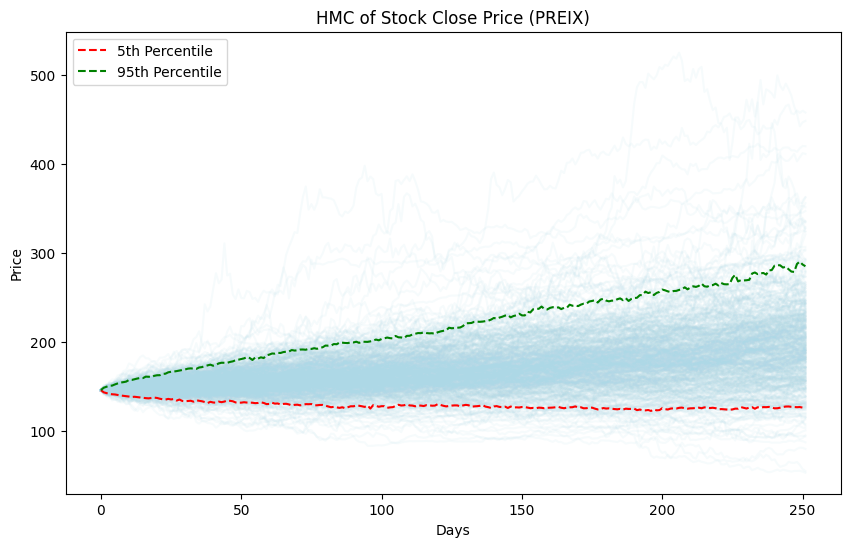

In [ ]:
import numpy as np
from scipy.stats import t

n_paths = 500
horizon = 252

h_sim = np.zeros(horizon)
r_sim = np.zeros(horizon)

#plt.figure()
all_paths = []
for i in range(n_paths):
    draw_idx = np.random.randint(len(posterior["phi"].values.flatten())) #for unbiased sampling doy

    h_sim = np.zeros(horizon)
    r_sim = np.zeros(horizon)
    price_sim = np.zeros(horizon)
    price_sim[0] = stock_data["Close"].iloc[-1]

    phi_draw = posterior["phi"].values.flatten()[draw_idx]
    sigma_eta_draw = posterior["sigma_eta"].values.flatten()[draw_idx]
    mu_draw = posterior["mu"].values.flatten()[draw_idx]
    nu_draw = posterior["nu"].values.flatten()[draw_idx]
    
    for n in range(1, horizon):
        #h_sim[n] = phi_draw * h_sim[n-1] + sigma_eta_draw * np.random.randn()
        h_sim[n] = mu_draw + phi_draw * (h_sim[n-1] - mu_draw) + sigma_eta_draw * np.random.randn() #centered at mu_draw rather than 0, more fair
        z = t.rvs(df=nu_draw)
        #z = z / np.sqrt(nu_draw / (nu_draw - 2)) #scales z val according to prev. scales
        r_sim[n] = mu_draw + np.exp(h_sim[n] / 2) * z #altered random (Gaussian dist) to match T
        price_sim[n] = price_sim[n-1] * np.exp(r_sim[n] / 100)
    
    #plt.plot(price_sim)
    all_paths.append(price_sim.copy())

sim_array = np.column_stack(all_paths)   # Convert to array

sim_paths_df = pd.DataFrame(sim_array)   # Convert to DataFrame

plt.figure(figsize=(10, 6))
plt.plot(sim_paths_df, color="lightblue", alpha=0.1)

# Add 5% and 95% percentile lines
percentiles_5 = sim_paths_df.quantile(0.05, axis=1)
percentiles_95 = sim_paths_df.quantile(0.95, axis=1)

plt.plot(percentiles_5, color="red", linestyle="--", label="5th Percentile")
plt.plot(percentiles_95, color="green", linestyle="--", label="95th Percentile")

# Add labels and title
ticker = "PREIX" #demo ticker remember
plt.title(f"HMC of Stock Close Price ({ticker})")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

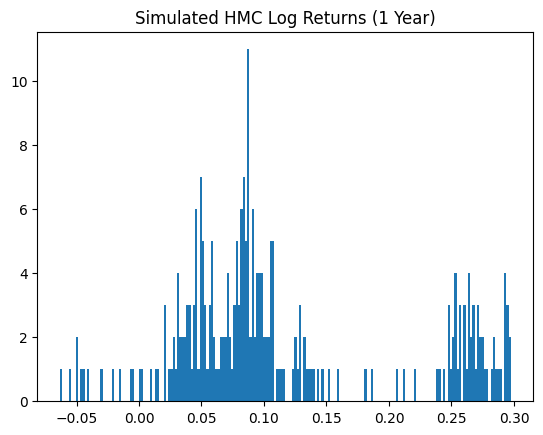

HMC mean: 0.11479097349136713
HMC median: 0.08707953906737734


In [22]:
final_prices = sim_paths_df.iloc[:, -1]

sim_total_log_return = np.log(final_prices / initial_price)

plt.hist(sim_total_log_return, bins=200)
plt.title("Simulated HMC Log Returns (1 Year)")
plt.show()

print("HMC mean:", sim_total_log_return.mean())
print("HMC median:", np.median(sim_total_log_return))



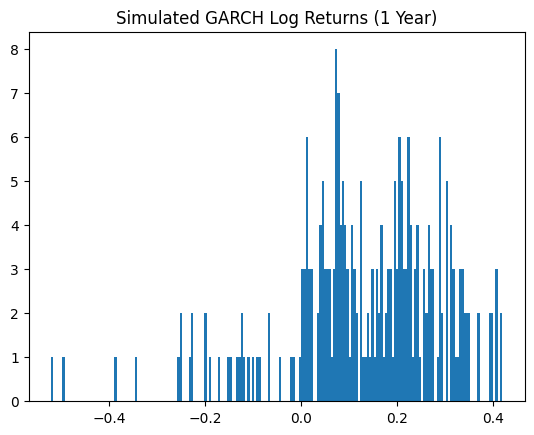

GARCH mean: 0.13398022495659
GARCH median: 0.14966939057544915


In [ ]:
prices = simulated_paths_df.iloc[:, -1]

sim_log_returns = np.log(prices / initial_price)

plt.hist(sim_log_returns, bins=200)
plt.title("Simulated GARCH Log Returns (1 Year)")
plt.show()

print("GARCH mean:", sim_log_returns.mean()) #label axes
print("GARCH median:", np.median(sim_log_returns))

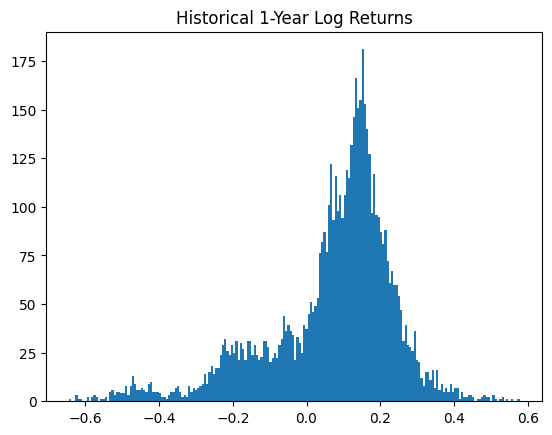

Real mean: 0.07083006531666412
Real median: 0.11231174025844097


In [24]:
log_returns = np.log(1 + stock_data['Daily Return'])

rolling_real = log_returns.rolling(252).sum().dropna()

plt.hist(rolling_real, bins=200)
plt.title("Historical 1-Year Log Returns")
plt.show()

print("Real mean:", rolling_real.mean())
print("Real median:", rolling_real.median())

In [34]:
# Risk Metrics

confidence_level = 0.95
alpha = 1 - confidence_level

# Final prices from simulation
last_sim_prices = sim_paths_df.iloc[-1].values

# --- 1. Empirical Confidence Interval (distribution-based) ---
lower_bound = np.percentile(last_sim_prices, alpha * 100)
upper_bound = np.percentile(last_sim_prices, (1 - alpha) * 100)

print("HMC EDITION")
print("----------------------------------")

print(f"95% Empirical Confidence Interval for Final Price: "
      f"({lower_bound:.2f}, {upper_bound:.2f})")

# --- 2. Dollar VaR (how much you could lose) ---
losses = initial_price - last_sim_prices
var_95 = np.percentile(losses, 95)

print(f"95% Value at Risk (Dollar): {var_95:.2f}")

# --- 3. Percentage VaR ---
percent_losses = losses / initial_price
var_95_pct = np.percentile(percent_losses, 95)

print(f"95% Value at Risk (%): {var_95_pct * 100:.2f}%")

# --- 4. Expected Shortfall (CVaR) ---
cvar_95 = losses[losses >= var_95].mean()
print(f"95% Expected Shortfall (CVaR): {cvar_95:.2f}")

# --- 5. Summary Stats ---
print("\nDistribution Diagnostics:")
print(f"Mean Final Price: {np.mean(last_sim_prices):.2f}")
print(f"Median Final Price: {np.median(last_sim_prices):.2f}")
print(f"Minimum Final Price: {np.min(last_sim_prices):.2f}")
print(f"Maximum Final Price: {np.max(last_sim_prices):.2f}")

HMC EDITION
----------------------------------
95% Empirical Confidence Interval for Final Price: (125.80, 284.72)
95% Value at Risk (Dollar): 19.68
95% Value at Risk (%): 13.53%
95% Expected Shortfall (CVaR): 38.72

Distribution Diagnostics:
Mean Final Price: 198.24
Median Final Price: 192.97
Minimum Final Price: 52.58
Maximum Final Price: 457.47


In [35]:
# Risk Metrics

confidence_level = 0.95
alpha = 1 - confidence_level

# Final prices from simulation
last_sim_prices = simulated_paths_df.iloc[-1].values

# --- 1. Empirical Confidence Interval (distribution-based) ---
lower_bound = np.percentile(last_sim_prices, alpha * 100)
upper_bound = np.percentile(last_sim_prices, (1 - alpha) * 100)

print("GARCH EDITION")
print("----------------------------------")

print(f"95% Empirical Confidence Interval for Final Price: "
      f"({lower_bound:.2f}, {upper_bound:.2f})")

# --- 2. Dollar VaR (how much you could lose) ---
losses = initial_price - last_sim_prices
var_95 = np.percentile(losses, 95)

print(f"95% Value at Risk (Dollar): {var_95:.2f}")

# --- 3. Percentage VaR ---
percent_losses = losses / initial_price
var_95_pct = np.percentile(percent_losses, 95)

print(f"95% Value at Risk (%): {var_95_pct * 100:.2f}%")

# --- 4. Expected Shortfall (CVaR) ---
cvar_95 = losses[losses >= var_95].mean()
print(f"95% Expected Shortfall (CVaR): {cvar_95:.2f}")

# --- 5. Summary Stats ---
print("\nDistribution Diagnostics:")
print(f"Mean Final Price: {np.mean(last_sim_prices):.2f}")
print(f"Median Final Price: {np.median(last_sim_prices):.2f}")
print(f"Minimum Final Price: {np.min(last_sim_prices):.2f}")
print(f"Maximum Final Price: {np.max(last_sim_prices):.2f}")

GARCH EDITION
----------------------------------
95% Empirical Confidence Interval for Final Price: (82.58, 360.02)
95% Value at Risk (Dollar): 62.90
95% Value at Risk (%): 43.24%
95% Expected Shortfall (CVaR): 98.94

Distribution Diagnostics:
Mean Final Price: 342.77
Median Final Price: 180.41
Minimum Final Price: 0.00
Maximum Final Price: 40088.25


Sampling: [r_obs]


Output()

Observed mean: 0.0570389210635322
Mean of HMC simulated means: 0.10752192683689771
Observed std: 1.1735396095893265
Mean of HMC simulated stds: 1.165653697386806
Observed kurtosis: 16.575369266340534
Simulated HMC kurtosis mean: 17.940979005700797


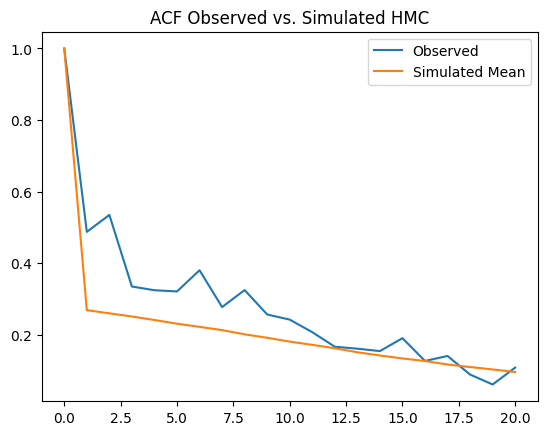

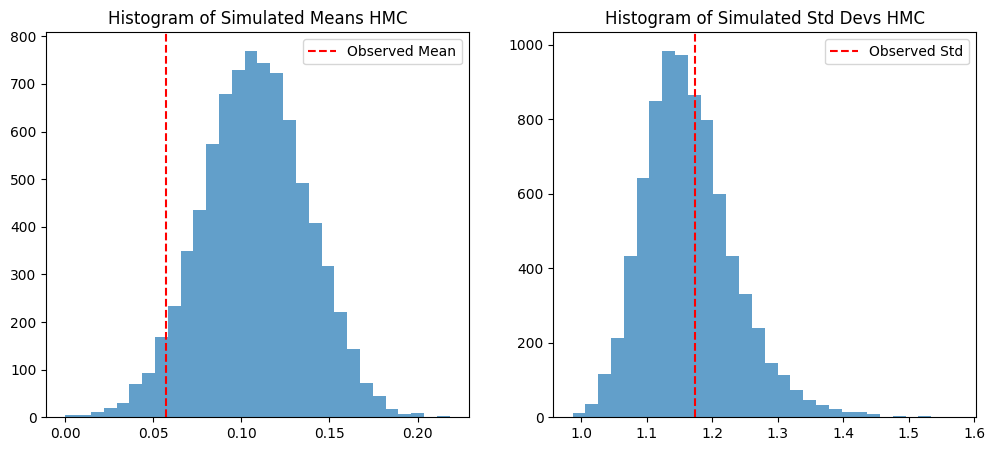

In [32]:
with stochastic_vol_model:
    ppc = pm.sample_posterior_predictive(trace)
    ppc_returns = ppc.posterior_predictive["r_obs"].values
    ppc_flat = ppc_returns.reshape(-1, ppc_returns.shape[-1])

    simulated_means = ppc_flat.mean(axis=1)
    simulated_stds = ppc_flat.std(axis=1)

    print("Observed mean:", returns.mean())
    print("Mean of HMC simulated means:", simulated_means.mean())

    print("Observed std:", returns.std())
    print("Mean of HMC simulated stds:", simulated_stds.mean())

    observed_kurtosis = pd.Series(returns).kurtosis()

    sim_kurtosis = [pd.Series(sim).kurtosis() for sim in ppc_flat]

    print("Observed kurtosis:", observed_kurtosis)
    print("Simulated HMC kurtosis mean:", np.mean(sim_kurtosis))

    from statsmodels.tsa.stattools import acf

    obs_acf = acf(returns**2, nlags=20)

    sim_acfs = [acf(sim**2, nlags=20) for sim in ppc_flat]

    mean_sim_acf = np.mean(sim_acfs, axis=0)

    plt.plot(obs_acf, label="Observed")
    plt.plot(mean_sim_acf, label="Simulated Mean")
    plt.legend()
    plt.title("ACF Observed vs. Simulated HMC")
    plt.show()

    # Optional: plot histogram of means and stds for simulation ensemble
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(simulated_means, bins=30, alpha=0.7)
plt.axvline(returns.mean(), color='red', linestyle='--', label='Observed Mean')
plt.title("Histogram of Simulated Means HMC")
plt.legend()

plt.subplot(1,2,2)
plt.hist(simulated_stds, bins=30, alpha=0.7)
plt.axvline(returns.std(), color='red', linestyle='--', label='Observed Std')
plt.title("Histogram of Simulated Std Devs HMC")
plt.legend()
plt.show()

Observed mean: 0.0570389210635322
Mean of simulated GARCH means: 0.0020511179705109644
Observed std: 1.1735396095893265
Mean of simulated GARCH stds: 0.029704805155821936
Observed kurtosis: 16.575369266340534
Simulated GARCH kurtosis mean: 4.88947689721099


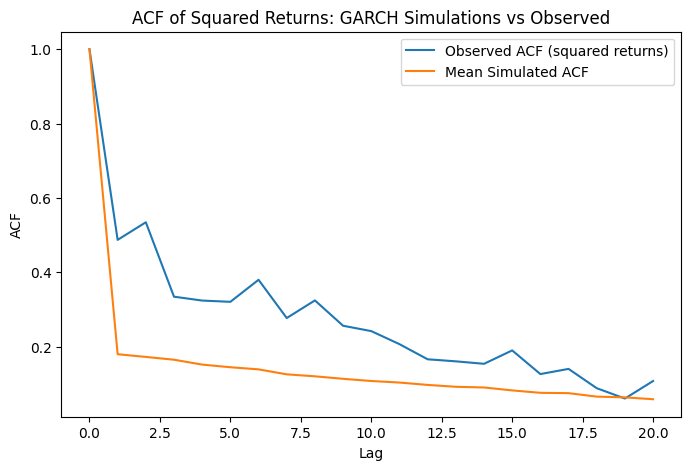

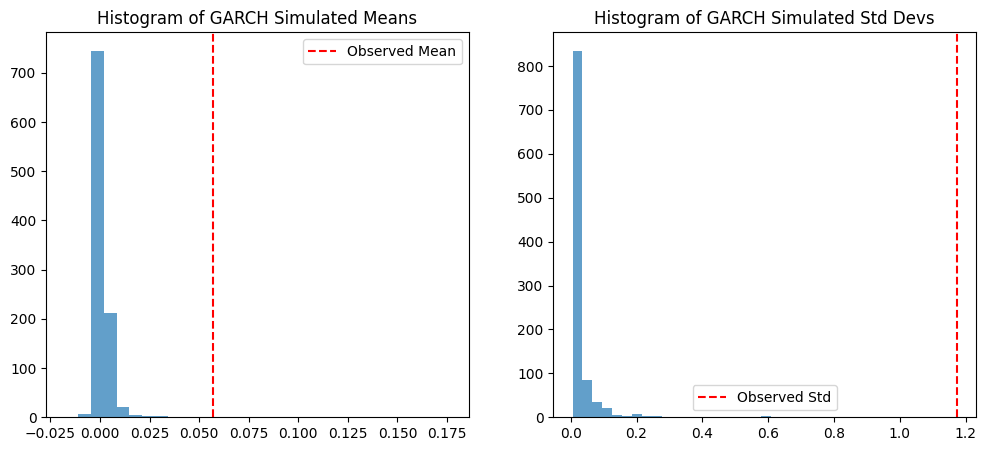

In [33]:

# 1. Convert simulated prices to daily returns
simulated_returns = simulated_paths_df.pct_change().dropna()  # fractional returns
sim_returns_array = simulated_returns.values.T  # shape: n_simulations x n_days

# 2. Compute mean and std for each simulated path
sim_means = sim_returns_array.mean(axis=1)
sim_stds = sim_returns_array.std(axis=1)

print("Observed mean:", returns.mean())
print("Mean of simulated GARCH means:", sim_means.mean())

print("Observed std:", returns.std())
print("Mean of simulated GARCH stds:", sim_stds.mean())

# 3. Kurtosis
observed_kurtosis = pd.Series(returns).kurtosis()
sim_kurtosis = [pd.Series(sim).kurtosis() for sim in sim_returns_array]

print("Observed kurtosis:", observed_kurtosis)
print("Simulated GARCH kurtosis mean:", np.mean(sim_kurtosis))

# 4. ACF of squared returns (volatility clustering)
obs_acf = acf(returns**2, nlags=20)

sim_acfs = [acf(sim**2, nlags=20) for sim in sim_returns_array]
mean_sim_acf = np.mean(sim_acfs, axis=0)

# 5. Plot comparison
plt.figure(figsize=(8,5))
plt.plot(obs_acf, label="Observed ACF (squared returns)")
plt.plot(mean_sim_acf, label="Mean Simulated ACF")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.title("ACF of Squared Returns: GARCH Simulations vs Observed")
plt.legend()
plt.show()

# Optional: plot histogram of means and stds for simulation ensemble
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(sim_means, bins=30, alpha=0.7)
plt.axvline(returns.mean(), color='red', linestyle='--', label='Observed Mean')
plt.title("Histogram of GARCH Simulated Means")
plt.legend()

plt.subplot(1,2,2)
plt.hist(sim_stds, bins=30, alpha=0.7)
plt.axvline(returns.std(), color='red', linestyle='--', label='Observed Std')
plt.title("Histogram of GARCH Simulated Std Devs")
plt.legend()
plt.show()

In [27]:
# --- SPLIT DATA ---
train_returns = returns[:-300]
test_returns = returns[-300:]

# --- FIT MODEL ON TRAIN ONLY ---
with build_sv_model(train_returns) as model: #abstract model building now rq b4 progression!
    #below from post_trace = pm.sample()
    post_trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.95,
        chains=4
    )

# --- EXTRACT POSTERIOR DRAWS ONCE ---
h_current = post_trace.posterior["h"].values[:, :, -1].reshape(-1)
phi_draws = post_trace.posterior["phi"].values.reshape(-1)
sigma_eta_draws = post_trace.posterior["sigma_eta"].values.reshape(-1)
mu_draws = post_trace.posterior["mu"].values.reshape(-1)
nu_draws = post_trace.posterior["nu"].values.reshape(-1)

/Users/mycomputer/Desktop/MCMC/.monVenv/lib/python3.14/site-packages/pymc/distributions/timeseries.py:595: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100, shape=...)`. You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, u, sigma_eta, h, nu_raw]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 145 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Filtered Empirical Coverage: 0.9666666666666667
Avg Interval Width: 3.577701060954261
Avg Log Predictive Likelihood: -1.1622516757085875
0.5011366666666667 0.07912610298888889


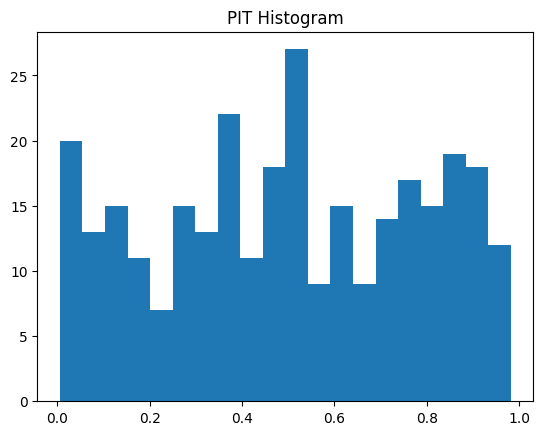

In [28]:
#sequential mc below w/ particles acting as weigted set
# --- initialize particles from posterior ---
n_particles = 2000

idx = np.random.choice(len(phi_draws), size=n_particles)

phi = phi_draws[idx]
sigma_eta = sigma_eta_draws[idx]
mu = mu_draws[idx]
nu = nu_draws[idx]

# initialize latent volatility from posterior
h_particles = h_current[idx]

coverage_count = 0
lower_bounds = []
upper_bounds = []
log_likelihoods = []
pit_values = []

for actual_return in test_returns:

    # --- PREDICT STEP ---
    noise = np.random.randn(n_particles)
    h_particles = (
        mu
        + phi * (h_particles - mu)
        + sigma_eta * noise
    ) #"based on yesterday, what is today"
    h_particles = np.clip(h_particles, -10, 5)

    # simulate predictive returns
    z = t.rvs(df=nu)
    r_particles = mu + np.exp(h_particles / 2) * z

    # --- COMPUTE INTERVAL ---
    pit = np.mean(r_particles <= actual_return)
    pit_values.append(pit)

    lower = np.percentile(r_particles, 2.5)
    upper = np.percentile(r_particles, 97.5)

    lower_bounds.append(lower)
    upper_bounds.append(upper)

    if lower <= actual_return <= upper:
        coverage_count += 1

    # --- WEIGHT UPDATE (LIKELIHOOD) ---
    scale = np.exp(h_particles / 2)

    likelihoods = t.pdf(
        actual_return,
        df=nu,
        loc=mu,
        scale=scale
    ) #this section is key, accts for tails and particle weighting

    # avoid collapse
    likelihoods += 1e-12
    weights = likelihoods / np.sum(likelihoods)

    # --- LOG PREDICTIVE LIKELIHOOD ---
    log_lik = np.log(np.mean(likelihoods))
    log_likelihoods.append(log_lik)

    # --- RESAMPLE ---
    resample_idx = np.random.choice( #picks good/bad particles apt accordingly
        np.arange(n_particles),
        size=n_particles,
        p=weights
    )

    h_particles = h_particles[resample_idx]
    phi = phi[resample_idx]
    sigma_eta = sigma_eta[resample_idx]
    mu = mu[resample_idx]
    nu = nu[resample_idx]

# --- RESULT ---
coverage_rate = coverage_count / len(test_returns)
print("Filtered Empirical Coverage:", coverage_rate)
print("Avg Interval Width:", np.mean(np.array(upper_bounds) - np.array(lower_bounds)))
print("Avg Log Predictive Likelihood:", np.mean(log_likelihoods))
print(np.mean(pit_values), np.var(pit_values))
plt.hist(pit_values, bins=20)
plt.title("PIT Histogram")
plt.show()

GARCH Coverage: 0.94
Avg Interval Width: 3.2279432705535775
GARCH Avg Log Likelihood: -1.179607062012179
0.49889833333333344 0.08656334549722222


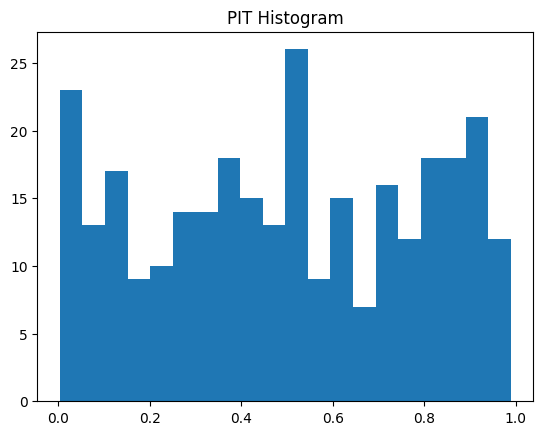

In [29]:

# --- FIT GARCH ON TRAIN ---
garch = arch_model(
    train_returns,
    mean='Constant',
    vol='GARCH',
    p=1,
    q=1,
    dist='t'
)

garch_res = garch.fit(disp="off")

params = garch_res.params
mu = params['mu']
omega = params['omega']
alpha = params['alpha[1]']
beta = params['beta[1]']
nu = params['nu']

# --- INITIAL STATE ---
sigma_t = garch_res.conditional_volatility[-1]
r_prev = garch_res.resid[-1]

coverage_count = 0
lower_bounds = []
upper_bounds = []
log_likelihoods = []
pit_values = []

# --- ROLL FORWARD ---
for actual_return in test_returns:

    # --- UPDATE VOLATILITY ---
    sigma2_t = omega + alpha * (r_prev ** 2) + beta * (sigma_t ** 2)
    sigma_t = np.sqrt(sigma2_t)

    # --- SIMULATE PREDICTIVE DISTRIBUTION ---
    n_sim = 2000
    z = np.random.standard_t(df=nu, size=n_sim)
    z = z / np.sqrt(nu / (nu - 2))  # normalize variance

    r_draws = mu + sigma_t * z

    # --- INTERVAL ---
    lower = np.percentile(r_draws, 2.5)
    upper = np.percentile(r_draws, 97.5)

    lower_bounds.append(lower)
    upper_bounds.append(upper)

    if lower <= actual_return <= upper:
        coverage_count += 1

    # --- LOG PREDICTIVE LIKELIHOOD ---
    scale = sigma_t
    likelihood = t.pdf(actual_return, df=nu, loc=mu, scale=scale)
    log_likelihoods.append(np.log(likelihood + 1e-12))

    # --- PIT ---
    pit = np.mean(r_draws <= actual_return)
    pit_values.append(pit)

    # --- UPDATE RESIDUAL ---
    r_prev = actual_return - mu

coverage_rate = coverage_count / len(test_returns)

print("GARCH Coverage:", coverage_rate)
print("Avg Interval Width:", np.mean(np.array(upper_bounds) - np.array(lower_bounds)))
print("GARCH Avg Log Likelihood:", np.mean(log_likelihoods))
print(np.mean(pit_values), np.var(pit_values))
plt.hist(pit_values, bins=20)
plt.title("PIT Histogram")
plt.show()
